### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 12</center>
---

### Overview

The objective of this exercise is to study the fundamentals of color image processing, the representation of color images in OpenCV, different color spaces, and some color image processing methods.

The following figure shows a visualization of the RGB (left) and HSI (right) color space:
<br />
<center><img src="images/rgb-hsi.png"  width="500px" /></center>

Note that the HSI color space (right) is also often modeled as a double hexagon (see lecture notes). For color mixing and selection, the HSI color space is more intuitive, because the color (hue) is defined by a single value / channel.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot image in original size
def plot_img_orig(img):
    fig = plt.figure(figsize = (img.shape[1]/dpi, img.shape[0]/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255) # cmap parameter is ignored for RGB(A) data
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 12.1</span> Working with Color Images

In OpenCV, images are read as BGR images by default (the B and R channels are switched) for historical reasons. To convert between different representations, the OpenCV function <a href="https://docs.opencv.org/4.2.0/d8/d01/group__imgproc__color__conversions.html#ga397ae87e1288a81d2363b61574eb8cab">`cv2.cvtColor` ↗</a> can be used. For example, `img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)` can be used to convert from BGR to RGB.

Implement / solve the following tasks:
    
1. Read the image *rgb-stripes.png* as a color image (RGB) and plot the result.
2. Store each color channel in a gray value image and plot it. Check the results for correctness.

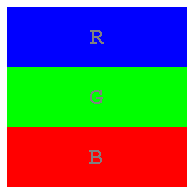

In [2]:
# read the image as bgr image (parameter 1)
img_bgr = cv2.imread('images/rgb-stripes.png', 1)

# plot image directly (note the bgr format)
plot_img_orig(img_bgr)

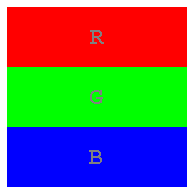

In [3]:
# convert bgr image to rgb
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plot_img_orig(img_rgb)

R


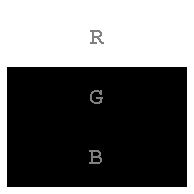

G


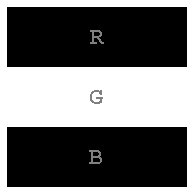

B


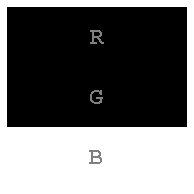

In [4]:
# access each channel using split
img_r, img_g, img_b = cv2.split(img_rgb)

print("R") 
plot_img_orig(img_r)

print("G") 
plot_img_orig(img_g)

print("B") 
plot_img_orig(img_b)

R


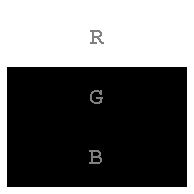

G


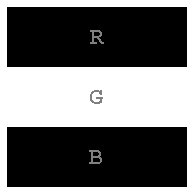

B


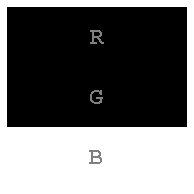

In [5]:
# access each channel using direct access
print("R") 
plot_img_orig(img_rgb[:,:,0])

print("G") 
plot_img_orig(img_rgb[:,:,1])

print("B") 
plot_img_orig(img_rgb[:,:,2])

#### <span style="color: RoyalBlue; font-weight: bold;">Task 12.2</span> RGB Color Space

As can be seen in the overview, different planes of the RGB cube can be obtained by setting one channel constant (e.g., $0$), while the other two channels are varied between $[0,255]$. Note the position of the origin of the RGB cube in comparison to image coordinates, which are usually counted from top left. In this task, the image coordinates can be used directly.

Implement / solve the following tasks:

1. Compute and plot the six outer sides (edges) of the RGB cube using images with a size of $256 \times 256$ pixels.

RG plane (bottom):


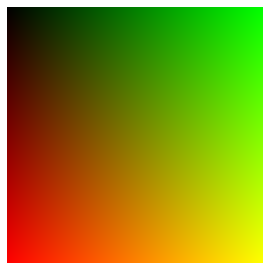

In [6]:
# RG plane (bottom)
rg = np.zeros((256, 256, 3), dtype=np.uint8) #3 channels, so 256x256x3

for iy in range(256):
    for jx in range(256):
        rg[iy, jx, 0] = iy    #0-th channel: R
        rg[iy, jx, 1] = jx    #1-st channel: G

print("RG plane (bottom):") 
plot_img_orig(rg)

RB plane (left):


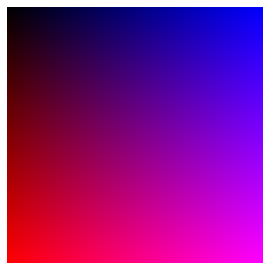

In [7]:
# RB plane (left)
rb = np.zeros((256, 256, 3), dtype=np.uint8)

for iy in range(256):
    for jx in range(256):
        rb[iy, jx, 0] = iy    #0-th channel: R
        rb[iy, jx, 2] = jx    #1-st channel: B

print("RB plane (left):") 
plot_img_orig(rb)

GB plane (back):


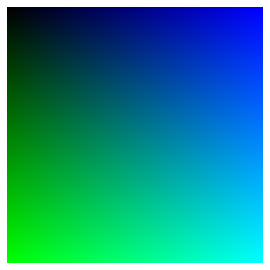

In [8]:
# GB plane (back)
gb = np.zeros((256, 256, 3), dtype=np.uint8)

for iy in range(256):
    for jx in range(256):
        gb[iy, jx, 1] = iy    #1st channel: B
        gb[iy, jx, 2] = jx    #2nd channel: G, #0-th channel: R kept as 0.

print("GB plane (back):") 
plot_img_orig(gb)

In [9]:
gb[0:255,0:255,0].any()&1

0

CM plane (top):


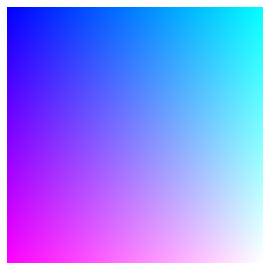

In [10]:
# CM plane (top)
cm = np.zeros((256, 256, 3), dtype=np.uint8)

for iy in range(256):
    for jx in range(256):
        cm[iy, jx, 0] = iy     #0-th channel: R
        cm[iy, jx, 1] = jx     #1-st channel: G
        cm[iy, jx, 2] = 255    #2-nd channel: B

print("CM plane (top):") 
plot_img_orig(cm)

CY plane (right):


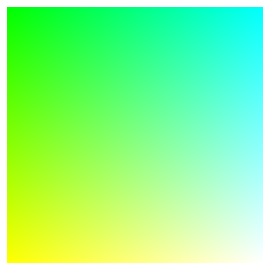

In [11]:
# CY plane (right)
cy = np.zeros((256, 256, 3), dtype=np.uint8)

for iy in range(256):
    for jx in range(256):
        cy[iy, jx, 0] = iy       #0-th channel: R
        cy[iy, jx, 1] = 255      #1-st channel: G
        cy[iy, jx, 2] = jx       #2-nd channel: B

print("CY plane (right):") 
plot_img_orig(cy)

MY plane (front):


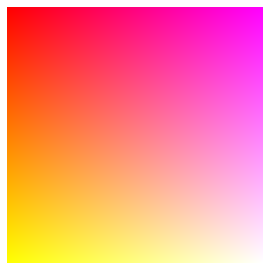

In [12]:
# MY plane (right)
my = np.zeros((256, 256, 3), dtype=np.uint8)

for iy in range(256):
    for jx in range(256):
        my[iy, jx, 0] = 255       #0-th channel: R
        my[iy, jx, 1] = iy        #1-st channel: G
        my[iy, jx, 2] = jx        #2-nd channel: B

print("MY plane (front):") 
plot_img_orig(my)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 12.3</span> HSV (HSI) Color Space

Even though there are around 150 <a href="https://docs.opencv.org/4.2.0/d8/d01/group__imgproc__color__conversions.html#ga4e0972be5de079fed4e3a10e24ef5ef0">color-space conversion methods available in OpenCV</a> (including YCbCr and CIE Lab), it does not directly support the HSI (hue, saturation, intensity) color space, but the HSV color space (hue, saturation, value). While both models use similar principles, they are not completely identical. The major difference is that the HSI color space uses a *double* cone or hexagon (see overview), while the HSV color space uses a *single* cone or hexagon (the lower part of the double cone with scaled intensity axis).

For the HSV color space in OpenCV, the hue range is $[0, 179]$, the saturation range is $[0, 255]$, and the value range is $[0, 255]$ (note that hue corresponds to an angle and 8 bit are used per channel). The corresponding conversion from RGB to HSV can be computed as follows (note that the conversion is different for the HSI color space):

Definitions: $\text{MAX} = \max{(R,G,B)}, \text{MIN} = \min{(R,G,B)}$

$
H = \left\{
\begin{array}{llll}
0°, & & & \text{if } \text{MAX = MIN} \Leftrightarrow R = G = B\\
0° &+& 60° \cdot \frac{(G-B)}{\text{MAX}-\text{MIN}}, & \text{if } \text{MAX = R}\\
120° &+& 60° \cdot \frac{(B-R)}{\text{MAX}-\text{MIN}}, & \text{if } \text{MAX = G}\\
240° &+& 60° \cdot \frac{(R-G)}{\text{MAX}-\text{MIN}}, & \text{if } \text{MAX = B}\\
\end{array}
\right.
$

$H = H + 360°, \text{if}\ H < 0$

$H = H/2$

$
S = \left\{
\begin{array}{ll}
0, & \text{if } \text{MAX = 0} \Leftrightarrow R = G = B = 0 \\
255\frac{\text{MAX}-\text{MIN}}{\text{MAX}}, & \textrm{otherwise} \\
\end{array}
\right.
$

$V = \text{MAX}$

Sometimes (but not here) it is required that $R, G, B \in [0, 1]$. $H$ is multiplied by $1/2$ to transform the angles from $[0°,360°]$ to $[0°,180°]$, because the maximum range of values for an 8 bit image is $[0,255]$.

Implement / solve the following tasks:
    
1. Implement a function to compute the HSV representation of a given RGB image based on the given formulas (algorithm).
2. Plot the different channels for some test images (e.g., *hue-0.png*, *hue-120.png*, *hue-240.png*).
3. Compare the results with the OpenCV conversion using the function <a href="https://docs.opencv.org/4.2.0/d8/d01/group__imgproc__color__conversions.html#ga397ae87e1288a81d2363b61574eb8cab">`cv2.cvtColor` ↗</a>.
4. Create an image with $300 \times 300$ pixels with a circular plot of all HSV colors (with full saturation and value).

In [13]:
# compute the corresponding hsv representation of given rgb image
def rgb2hsv(img):
    res = np.zeros(img.shape, dtype=np.uint8) # init (rows x cols x 3) image with zeros
    
    # iterate over the image
    for iy in range(img.shape[0]):
        for jx in range(img.shape[1]):
            # store current set of rgb values in a new array
            rgb = np.array([img[iy, jx, 0], 
                            img[iy, jx, 1], 
                            img[iy, jx, 2]], dtype=np.float64)
            
            # get minimum and maximum
            rgb_min = np.min(rgb) 
            rgb_max = np.max(rgb)
            
            # hue
            hue = 0 # temporary variable because we have intermediate values > 255
            if (rgb_max == rgb_min):
                hue = 0
            elif (rgb_max == rgb[0]):
                hue = 60 * (rgb[1]-rgb[2]) / (rgb_max-rgb_min)
            elif (rgb_max == rgb[1]):
                hue = 120 + 60 * (rgb[2]-rgb[0]) / (rgb_max-rgb_min)
            elif (rgb_max == rgb[2]):
                hue = 240 + 60 * (rgb[0]-rgb[1]) / (rgb_max-rgb_min)

            # add 360 if h < 0
            if (hue < 0):
                hue = hue + 360
            
            # transform angles from [0, 360] to [0, 180]
            res[iy, jx, 0] = hue / 2
            
            # saturation
            if (rgb_max == 0):
                res[iy, jx, 1] = 0 # actually not required because of init with zeros
            else:
                res[iy, jx, 1] = 255 * (rgb_max-rgb_min) / (rgb_max)
                
            # value
            res[iy, jx, 2] = rgb_max
            
    # return result (hsv image)
    return res

Input image:


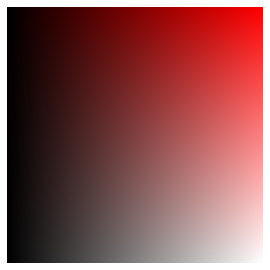

In [14]:
# read the image as bgr image (parameter 1) and convert to rgb
img_bgr = cv2.imread('images/hue-0.png', 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print("Input image:")
plot_img_orig(img_rgb)

H


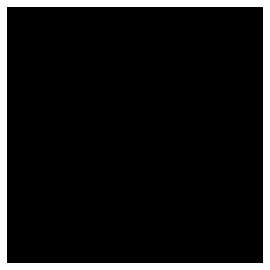

S


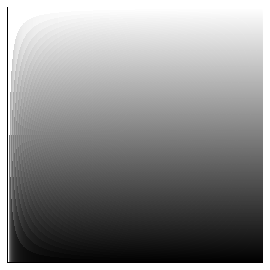

V


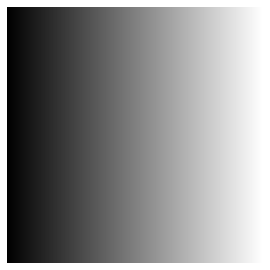

In [15]:
# test the function
img_hsv = rgb2hsv(img_rgb)

# plot the different channels
print("H") 
plot_img_orig(img_hsv[:,:,0])

print("S") 
plot_img_orig(img_hsv[:,:,1])

print("V") 
plot_img_orig(img_hsv[:,:,2])

H


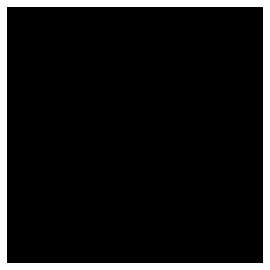

S


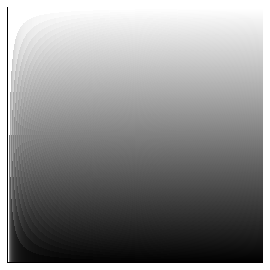

V


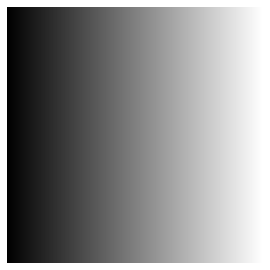

In [16]:
# compare the results with OpenCV
img_hsv_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
print("H") 
plot_img_orig(img_hsv_cv[:,:,0])

print("S") 
plot_img_orig(img_hsv_cv[:,:,1])

print("V") 
plot_img_orig(img_hsv_cv[:,:,2])

HSV plane with S=V=255:


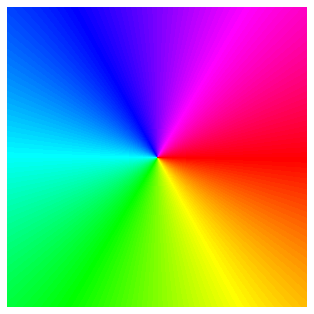

In [17]:
# circular plot of all colors as a plane based on the angle to the center
hsv = np.zeros((300, 300, 3), dtype=np.uint8)
hsv[:,:,1] = 255 # full saturation
hsv[:,:,2] = 255 # full value (brightness / intensity)

# compute center coordinates
cm = int(hsv.shape[0] / 2) # row
cn = int(hsv.shape[1] / 2) # col

# iterate over image
for i in range(hsv.shape[0]):
    for j in range(hsv.shape[1]):
        # compute angle
        angle = np.arctan2(i-cm, j-cn) # returns values in [-pi, pi]
        angle = angle * 180/np.pi # conversion to degree 
        
        # map to [0, 360]
        if (angle < 0):
            angle = angle + 360
            
        # in OpenCV, hue is in [0, 180]
        angle = angle / 2
        
        # assign angle to hue channel
        hsv[i, j, 0] = angle
        
# convert the image to rgb for plot
hsv_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
print("HSV plane with S=V=255:")
plot_img_orig(hsv_rgb)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 12.4</span> Intensity Slicing

Intensity slicing is a variant of pseudo color (or false color) image processing, where colors are assigned to pixels based on a specific criterion (intensity value). The HSI or HSV color space is particularly helpful for this purpose, because the color can be controlled directly by one variable (hue). For this task, use the image *mri-brain.png* and assume that the gray value corresponds to brain activity, which should be encoded with colors from blue to red, starting with a specific minimum activity (actually, the image is an MRI structure image and only shows the brain structure, not the activity).

Implement / solve the following tasks:
    
1. Read the image *mri-brain.png* as a grayscale image and plot it.
2. Map the input gray values to the colors from blue to red, for gray value larger than 100.

*Note*: The mapping can be seen as a transformation similar to range scaling (a linear mapping function from the grayvalue to the hue value).

Input image:


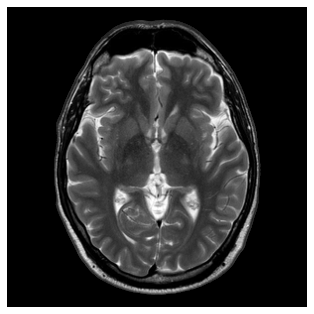

In [18]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/mri-brain.png', 0)
print("Input image:")
plot_img_orig(img)

Result:


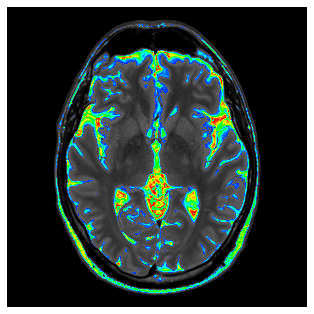

In [19]:
# slice from blue to red (hue from 120 to 0 deg)
# this means we have a transformation from [a, b] to [c, d] = [120, 0]
rows, cols = img.shape
hsv = np.zeros((rows, cols, 3), dtype=np.uint8)
hsv[:,:,1] = 0
hsv[:,:,2] = 0

# compute parameters of mapping function (which is a straight line y = f(x) = mx + b)
a = 100 #grayval greater than 100, from Ques
b = 255 #highest grayval
c = 120 #hue space, from 120 to 0
d = 0 # intervals, from 120 to 0 degree
m = (d-a) / (c-d) #slope, (-ve), bc in hue space, it comes from 120deg down to 0 degree
b = a - m * c #y-intercept, so from 255 down to 100, it changes from blue to red.

# iterate over image
for row in range(rows):
    for col in range(cols):
        if img[row, col] > a:
            hsv[row, col, 0] = m * img[row, col] + b #hue
            hsv[row, col, 1] = 255 #saturation
            hsv[row, col, 2] = 255 #value
        else:
            hsv[row, col, 2] = img[row, col] # overlay on original image (optional)

# convert the image to rgb for plot
hsv_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
print("Result:")
plot_img_orig(hsv_rgb)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 12.5</span> Pseudo-color Enhancement

Another example for pseudo color (or false color) image processing is the x-ray based luggage control at the airport. In this case, one method to assign pseudocolors is a mapping based on sine waves, where each sine wave has a small phase shift. The main idea is that pixels with (maybe critical) intensity values fall in the steep sections of the sine waves so that these get a higher color contrast than the sections around the maxima (the values change more slowly here).

Implement / solve the following tasks:
    
1. Read the image *x-ray-small.png* as a grayscale image and plot it.
2. Map the input gray values to RGB colors using sine waves and plot the result

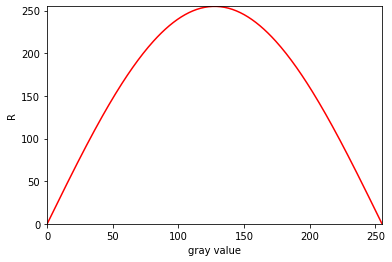

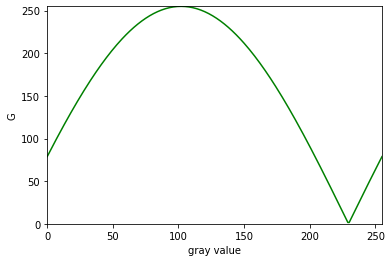

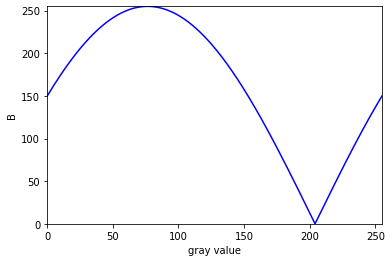

In [20]:
# create array with gray values from [0,255]
gray = np.arange(0, 256)

# compute sine waves with same frequency and small phase shift
f = 0.5 # frequency per 255 gray values
r = 255 * np.absolute(np.sin(f*(2*np.pi/255)*gray + 0.0*np.pi))
g = 255 * np.absolute(np.sin(f*(2*np.pi/255)*gray + 0.1*np.pi))
b = 255 * np.absolute(np.sin(f*(2*np.pi/255)*gray + 0.2*np.pi))

# plot the sine waves
plt.plot(gray, r, 'r') 
plt.xlim([0, 255]) 
plt.ylim([0, 255])
plt.xlabel("gray value")
plt.ylabel("R"); plt.show()

plt.plot(gray, g, 'g')
plt.xlim([0, 255]) 
plt.ylim([0, 255]) 
plt.xlabel("gray value") 
plt.ylabel("G"); plt.show()

plt.plot(gray, b, 'b') 
plt.xlim([0, 255]) 
plt.ylim([0, 255]) 
plt.xlabel("gray value") 
plt.ylabel("B"); plt.show()

Input image:


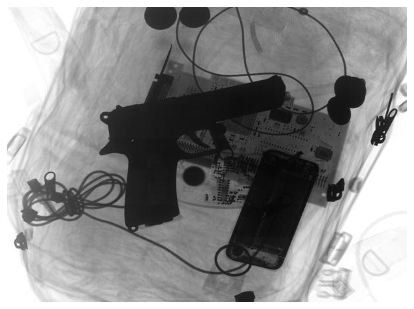

In [21]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/x-ray-small.png', 0)
print("Input image:")
plot_img_orig(img)

Result:


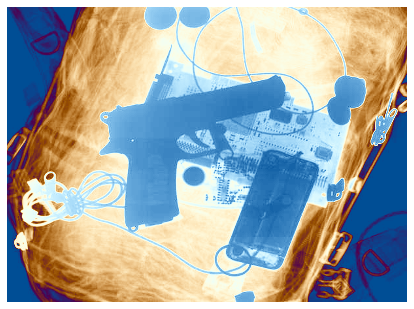

In [22]:
# create rgb image
rows, cols = img.shape # image size
rgb = np.zeros((rows, cols, 3), dtype=np.uint8)

# iterate over image
for row in range(rows):
    for col in range(cols):
        rgb[row, col, 0] = r[img[row, col]]
        rgb[row, col, 1] = g[img[row, col]]
        rgb[row, col, 2] = b[img[row, col]]

# plot the result
print("Result:")
plot_img_orig(rgb)